<a href="https://colab.research.google.com/github/ayushmanpathak9034/Insurance-Claim-Prediction/blob/main/Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Insurance Claim Prediction - Logistic Regression Model

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Load Dataset

In [ ]:
# Load the insurance dataset
insurance_df = pd.read_csv('/content/insurance.csv')
print('Shape:', insurance_df.shape)
display(insurance_df.head())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Basic info and data types
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Statistical summary
display(insurance_df.describe())

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 2. Null Value Treatment

In [ ]:
# Check null counts before treatment
print('Null values before treatment:')
print(insurance_df.isnull().sum())

# The insurance dataset does not have any null values, so no treatment is needed.
# This step is included for consistency with the previous notebook's structure.
print('\nNull values after treatment (no nulls to treat in this dataset):')
print(insurance_df.isnull().sum())

Null values before treatment:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Null values after treatment (no nulls to treat in this dataset):
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### 3. Label Encoding (Categorical → Numeric)

In [ ]:
# Encode object columns using LabelEncoder
le = LabelEncoder()
cat_cols_insurance = insurance_df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols_insurance)

for col in cat_cols_insurance:
    insurance_df[col] = le.fit_transform(insurance_df[col].astype(str))

display(insurance_df.head())

Categorical columns: ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### 4. Outlier Detection & Removal using IQR Method

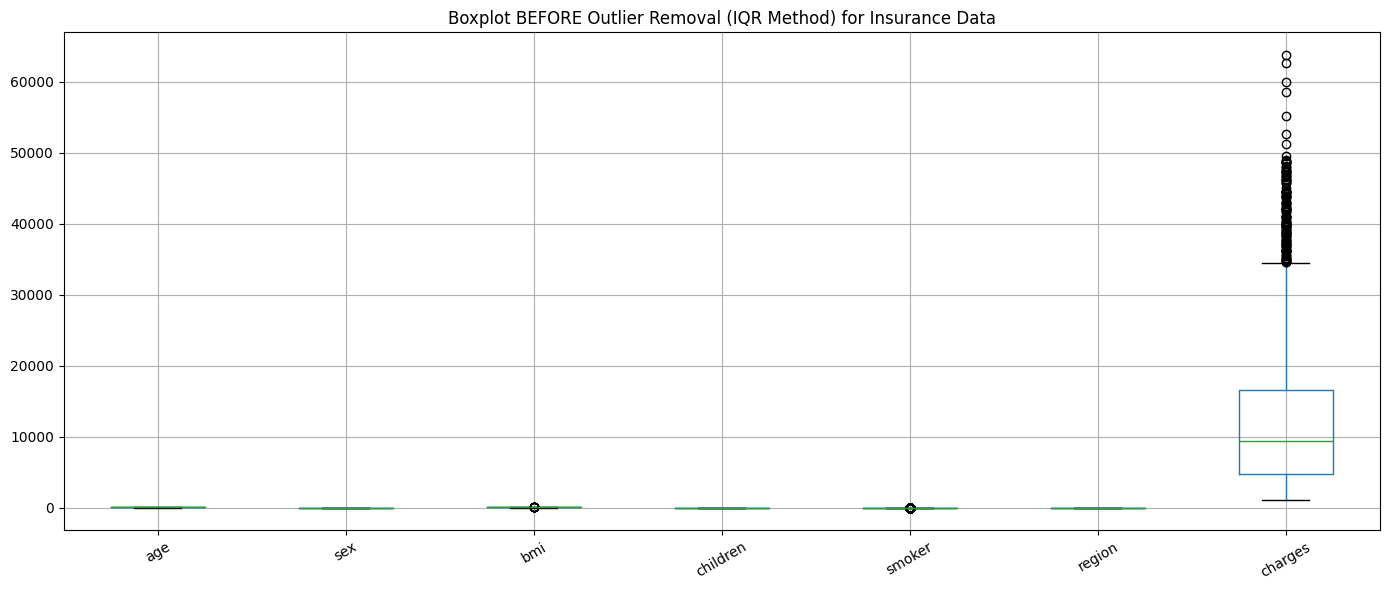

Rows before outlier removal: 1338
Rows after outlier removal: 1012


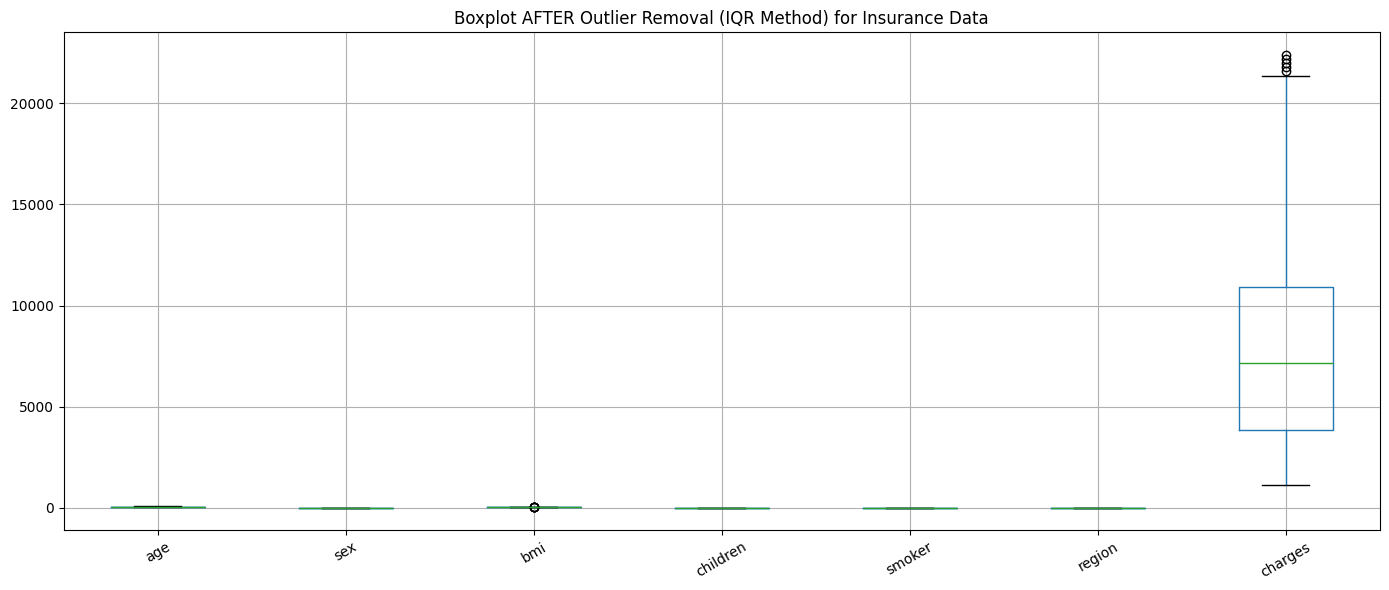

In [ ]:
# Create a copy to perform outlier removal
insurance_df_cleaned = insurance_df.copy()

# Select numeric columns for outlier treatment (excluding the target 'charges' for now, as we'll binarize it later)
num_cols_for_outliers_insurance = insurance_df_cleaned.select_dtypes(include=np.number).columns.tolist()

# ---- BEFORE Boxplot ----
plt.figure(figsize=(14, 6))
insurance_df_cleaned[num_cols_for_outliers_insurance].boxplot(rot=30)
plt.title('Boxplot BEFORE Outlier Removal (IQR Method) for Insurance Data')
plt.tight_layout()
plt.show()

# Apply IQR method to remove outliers
print('Rows before outlier removal:', len(insurance_df_cleaned))

for col in num_cols_for_outliers_insurance:
    Q1 = insurance_df_cleaned[col].quantile(0.25)
    Q3 = insurance_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    insurance_df_cleaned = insurance_df_cleaned[(insurance_df_cleaned[col] >= lower) & (insurance_df_cleaned[col] <= upper)]

print('Rows after outlier removal:', len(insurance_df_cleaned))

# ---- AFTER Boxplot ----
plt.figure(figsize=(14, 6))
insurance_df_cleaned[num_cols_for_outliers_insurance].boxplot(rot=30)
plt.title('Boxplot AFTER Outlier Removal (IQR Method) for Insurance Data')
plt.tight_layout()
plt.show()

In [ ]:
# Create a binary target variable 'Claim_Status' for logistic regression
# We'll define a claim as 'high' (1) if charges are above the median, and 'low' (0) otherwise.
median_charges = insurance_df_cleaned['charges'].median()
insurance_df_cleaned['Claim_Status'] = (insurance_df_cleaned['charges'] > median_charges).astype(int)

print('Claim_Status distribution:')
print(insurance_df_cleaned['Claim_Status'].value_counts())
display(insurance_df_cleaned.head())

Claim_Status distribution:
Claim_Status
0    506
1    506
Name: count, dtype: int64


,age,sex,bmi,children,smoker,region,charges,Claim_Status
1,18,1,33.770,1,0,2,1725.55230,0
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,1
4,32,1,28.880,0,0,1,3866.85520,0
5,31,0,25.740,0,0,2,3756.62160,0


### 5. Visualizations

/tmp/ipykernel_1973/2049419971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Claim_Status', data=insurance_df_cleaned, palette='Set2')


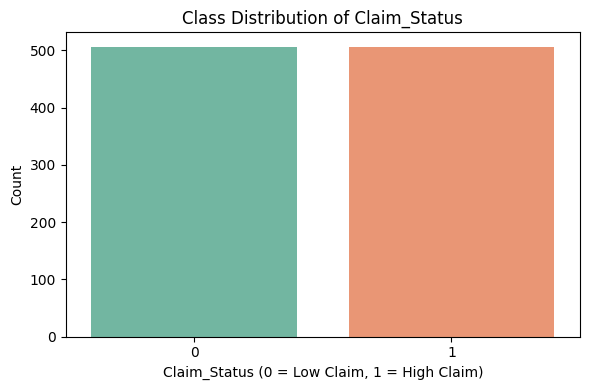

In [ ]:
# --- Visualization 1: Target class distribution (Countplot) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Claim_Status', data=insurance_df_cleaned, palette='Set2')
plt.title('Class Distribution of Claim_Status')
plt.xlabel('Claim_Status (0 = Low Claim, 1 = High Claim)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 6. Model Training - Logistic Regression

In [ ]:
# Define features (X) and target (y)
# Exclude 'charges' as it was used to create 'Claim_Status' and is not a feature for prediction.
X_insurance = insurance_df_cleaned.drop(columns=['charges', 'Claim_Status'])
y_insurance = insurance_df_cleaned['Claim_Status']

# Split into train and test sets (80/20)
X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance, y_insurance, test_size=0.2, random_state=42, stratify=y_insurance
)

print('Train size:', X_train_insurance.shape)
print('Test size :', X_test_insurance.shape)

Train size: (809, 6)
Test size : (203, 6)


In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train_insurance, y_train_insurance)
print('Model training complete.')

Model training complete.


In [ ]:
# Predictions on test set
y_pred = model.predict(X_test_insurance)

# Accuracy
acc = accuracy_score(y_test_insurance, y_pred)
print(f'Accuracy: {acc:.4f}')

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test_insurance, y_pred))

Accuracy: 0.9310

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       102
           1       0.91      0.95      0.93       101

    accuracy                           0.93       203
   macro avg       0.93      0.93      0.93       203
weighted avg       0.93      0.93      0.93       203



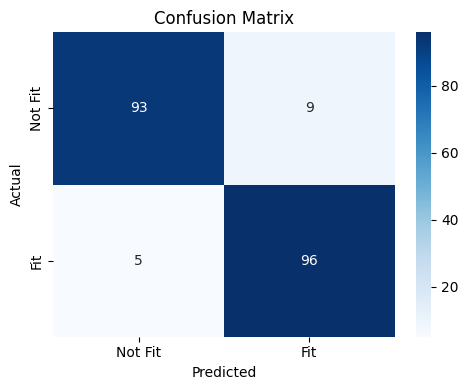

In [ ]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_test_insurance, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fit', 'Fit'],
            yticklabels=['Not Fit', 'Fit'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()